<a href="https://colab.research.google.com/github/swethasasikumar73/REAL-VS-AI/blob/main/Real_vs_AI_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf

print(tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2.20.0
GPU Available: []


In [6]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [7]:
import zipfile
import os

zip_path = "/content/archive (4).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
os.listdir("/content/dataset")

['real_dataset', 'Ai_generated_dataset']

In [9]:
import os

print("Files and folders inside /content:")
print(os.listdir("/content"))

Files and folders inside /content:
['.config', 'archive (4).zip', 'dataset', 'sample_data']


In [10]:
import os

print("Inside /content/dataset:")
print(os.listdir("/content/dataset"))

Inside /content/dataset:
['real_dataset', 'Ai_generated_dataset']


In [11]:
import zipfile
import os

zip_path = "/content/archive (4).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [12]:
import os

print(os.listdir("/content/dataset"))

['real_dataset', 'Ai_generated_dataset']


In [13]:
import os

ai_path = "/content/dataset/Ai_generated_dataset"
real_path = "/content/dataset/real_dataset"

print("AI dataset contents:")
print(os.listdir(ai_path))

print("\nReal dataset contents:")
print(os.listdir(real_path))

AI dataset contents:
['people', 'food', 'nature', 'city', 'animals']

Real dataset contents:
['people', 'food', 'nature', 'city', 'animals']


In [14]:
import os

ai_path = "/content/dataset/Ai_generated_dataset"
real_path = "/content/dataset/real_dataset"

image_extensions = (".jpg", ".jpeg", ".png", ".webp")

def count_images(folder):
    count = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(image_extensions):
                count += 1
    return count

print("IMAGE COUNT")
print("=" * 40)

total_ai = count_images(ai_path)
total_real = count_images(real_path)

print("AI-generated images :", total_ai)
print("Real images         :", total_real)
print("Total images        :", total_ai + total_real)

IMAGE COUNT
AI-generated images : 250
Real images         : 745
Total images        : 995


In [15]:
categories = ["food", "people", "city", "nature", "animals"]

print("CATEGORY-WISE IMAGE COUNT")
print("=" * 50)

for category in categories:
    ai_category_path = os.path.join(ai_path, category)
    real_category_path = os.path.join(real_path, category)

    ai_count = count_images(ai_category_path)
    real_count = count_images(real_category_path)

    print(f"\n{category.upper()}")
    print("  AI images   :", ai_count)
    print("  Real images :", real_count)
    print("  Total       :", ai_count + real_count)

CATEGORY-WISE IMAGE COUNT

FOOD
  AI images   : 50
  Real images : 150
  Total       : 200

PEOPLE
  AI images   : 50
  Real images : 147
  Total       : 197

CITY
  AI images   : 50
  Real images : 150
  Total       : 200

NATURE
  AI images   : 50
  Real images : 150
  Total       : 200

ANIMALS
  AI images   : 50
  Real images : 148
  Total       : 198


In [16]:
import os
import pandas as pd

from sklearn.model_selection import train_test_split

In [17]:
import os

print("Current /content:")
print(os.listdir("/content"))

print("\nCurrent /content/dataset:")
print(os.listdir("/content/dataset"))

print("\nChecking paths:")
print("dataset exists:", os.path.exists("/content/dataset"))
print("AI folder exists:", os.path.exists("/content/dataset/AI_generated_dataset"))
print("Real folder exists:", os.path.exists("/content/dataset/real_dataset"))

Current /content:
['.config', 'archive (4).zip', 'dataset', 'sample_data']

Current /content/dataset:
['real_dataset', 'Ai_generated_dataset']

Checking paths:
dataset exists: True
AI folder exists: False
Real folder exists: True


In [18]:
import os
import pandas as pd

# Correct folder names
ai_path = "/content/dataset/Ai_generated_dataset"
real_path = "/content/dataset/real_dataset"

# Image formats
image_extensions = (".jpg", ".jpeg", ".png", ".webp")

# Empty list
data = []

# Collect AI-generated images
for category in os.listdir(ai_path):
    category_path = os.path.join(ai_path, category)

    if os.path.isdir(category_path):
        for root, dirs, files in os.walk(category_path):
            for file in files:
                if file.lower().endswith(image_extensions):

                    file_path = os.path.join(root, file)

                    data.append({
                        "image_path": file_path,
                        "label": 1,
                        "class": "AI",
                        "category": category
                    })

# Collect Real images
for category in os.listdir(real_path):
    category_path = os.path.join(real_path, category)

    if os.path.isdir(category_path):
        for root, dirs, files in os.walk(category_path):
            for file in files:
                if file.lower().endswith(image_extensions):

                    file_path = os.path.join(root, file)

                    data.append({
                        "image_path": file_path,
                        "label": 0,
                        "class": "Real",
                        "category": category
                    })

# Create DataFrame
df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Total images:", len(df))

Dataset created successfully!
Total images: 995


In [19]:
df.head()

,image_path,label,class,category
0,/content/dataset/Ai_generated_dataset/people/i...,1,AI,people
1,/content/dataset/Ai_generated_dataset/people/i...,1,AI,people
2,/content/dataset/Ai_generated_dataset/people/i...,1,AI,people
3,/content/dataset/Ai_generated_dataset/people/i...,1,AI,people
4,/content/dataset/Ai_generated_dataset/people/i...,1,AI,people


In [20]:
#Checking class balance
print("Class distribution:")
print(df["class"].value_counts())

Class distribution:
class
Real    745
AI      250
Name: count, dtype: int64


In [21]:
#categorywise images
print("\nCategory distribution:")
print(df["category"].value_counts())


Category distribution:
category
food       200
city       200
nature     200
animals    198
people     197
Name: count, dtype: int64


In [22]:
print("\nClass + Category distribution:")
print(pd.crosstab(df["category"], df["class"]))


Class + Category distribution:
class     AI  Real
category          
animals   50   148
city      50   150
food      50   150
nature    50   150
people    50   147


In [23]:
#before splitting suffling the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.head())

                                          image_path  label class category
0  /content/dataset/real_dataset/animals/animals_...      0  Real  animals
1    /content/dataset/real_dataset/food/food_128.jpg      0  Real     food
2  /content/dataset/real_dataset/nature/nature_61...      0  Real   nature
3  /content/dataset/real_dataset/nature/nature_12...      0  Real   nature
4  /content/dataset/real_dataset/nature/nature_51...      0  Real   nature


In [24]:
#Create Training and Temporary sets
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Temporary images:", len(temp_df))

Training images: 796
Temporary images: 199


In [25]:
#Divide Temporary into Validation and Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

Training images   : 796
Validation images : 99
Testing images    : 100


In [26]:
#Verifying the split
print("TRAINING")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTESTING")
print(test_df["class"].value_counts())

TRAINING
class
Real    596
AI      200
Name: count, dtype: int64

VALIDATION
class
Real    74
AI      25
Name: count, dtype: int64

TESTING
class
Real    75
AI      25
Name: count, dtype: int64


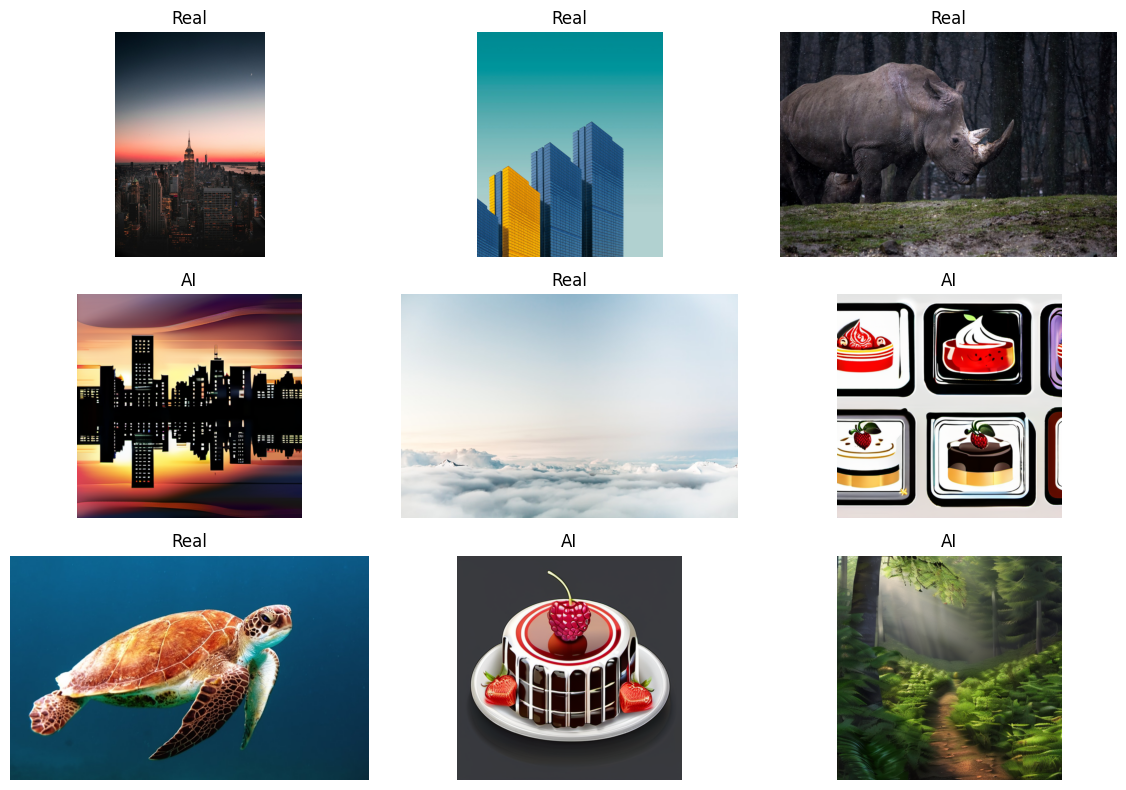

In [27]:
#Checking whether images are loading correctly
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

for i in range(9):
    image_path = train_df.iloc[i]["image_path"]
    label = train_df.iloc[i]["class"]

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
print("Complete dataset:")
print(df["class"].value_counts())

Complete dataset:
class
Real    745
AI      250
Name: count, dtype: int64


In [29]:
# Separate the two classes
real_df = df[df["label"] == 0]
ai_df = df[df["label"] == 1]

# Use the smaller class size
n_samples = min(len(real_df), len(ai_df))

# Randomly select the same number from both classes
real_balanced = real_df.sample(n=n_samples, random_state=42)
ai_balanced = ai_df.sample(n=n_samples, random_state=42)

# Combine them
balanced_df = pd.concat(
    [real_balanced, ai_balanced],
    ignore_index=True
)

# Shuffle
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced dataset:")
print(balanced_df["class"].value_counts())
print("Total images:", len(balanced_df))

Balanced dataset:
class
AI      250
Real    250
Name: count, dtype: int64
Total images: 500


In [30]:
#Training + temporary set
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.20,
    stratify=balanced_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Temporary:", len(temp_df))

Training: 400
Temporary: 100


In [31]:
#Validation + testing
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

Training images   : 400
Validation images : 50
Testing images    : 50


In [32]:
#Verify the New Split
print("TRAINING")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTESTING")
print(test_df["class"].value_counts())

TRAINING
class
AI      200
Real    200
Name: count, dtype: int64

VALIDATION
class
Real    25
AI      25
Name: count, dtype: int64

TESTING
class
AI      25
Real    25
Name: count, dtype: int64


In [33]:
#Set image parameters
IMG_SIZE = 224
BATCH_SIZE = 32

In [34]:
#creating a function
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [35]:
#Training dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(1000)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [36]:
#Validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [37]:
#Test dataset
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [38]:
#Check the Preprocessed Images
images, labels = next(iter(train_dataset))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 3)
Label shape: (32,)


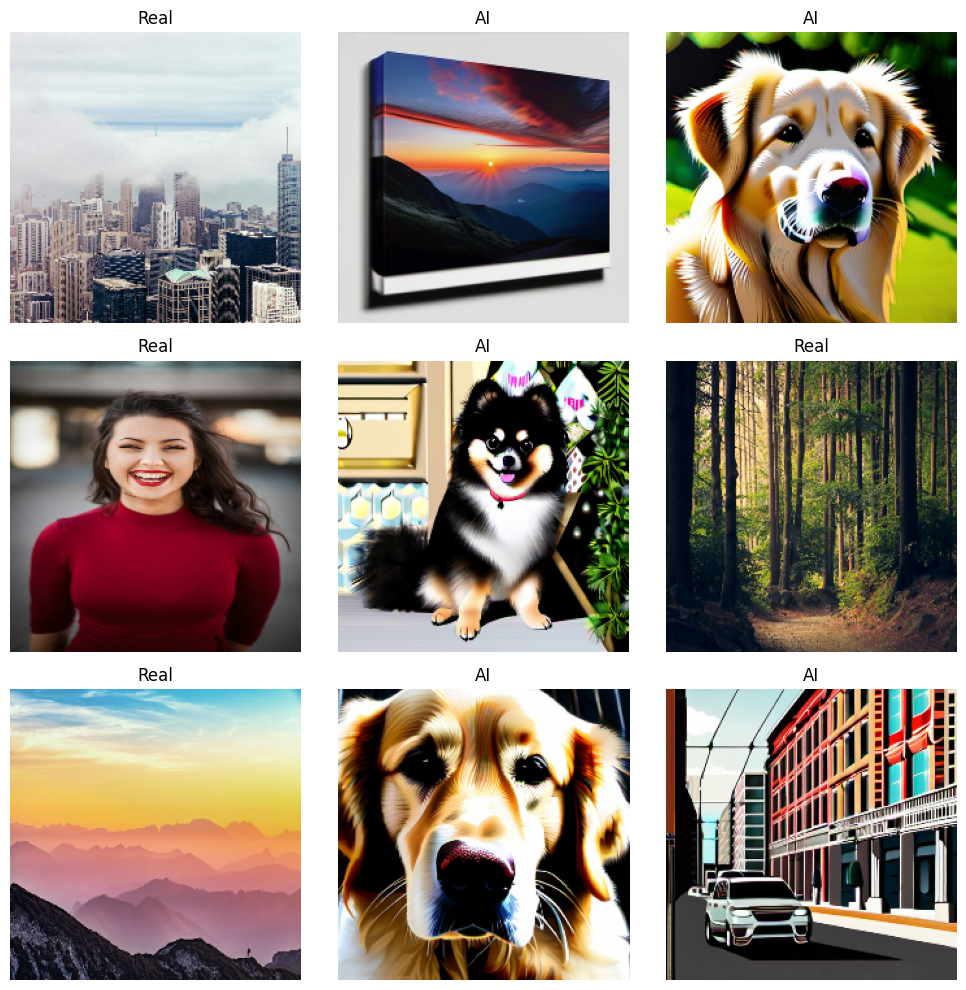

In [39]:
#Display Preprocessed Images
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    if labels[i].numpy() == 0:
        title = "Real"
    else:
        title = "AI"

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
#Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [41]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [42]:
model = models.Sequential([

    # Input layer
    layers.Input(shape=(224, 224, 3)),

    # Data Augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into one-dimensional vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Prevent overfitting
    layers.Dropout(0.5),

    # Binary classification output
    layers.Dense(1, activation='sigmoid')
])

In [43]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
print("GPU Available:")
print(tf.config.list_physical_devices('GPU'))

GPU Available:
[]


In [46]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 68s 5s/step - accuracy: 0.5700 - loss: 0.7602 - val_accuracy: 0.6000 - val_loss: 0.5885
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.7325 - loss: 0.5543 - val_accuracy: 0.7400 - val_loss: 0.4945
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.7425 - loss: 0.5115 - val_accuracy: 0.7600 - val_loss: 0.4866
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.7850 - loss: 0.4715 - val_accuracy: 0.7600 - val_loss: 0.4311
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.8025 - loss: 0.4327 - val_accuracy: 0.8000 - val_loss: 0.3649
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.8100 - loss: 0.4203 - val_accuracy: 0.8000 - val_loss: 0.4150
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.8150 - loss: 0.3902 - val_accuracy: 0.8000 - val_loss: 0.3771
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.8200 - loss: 0.3793 - val_accuracy: 0.7600 - val_loss:

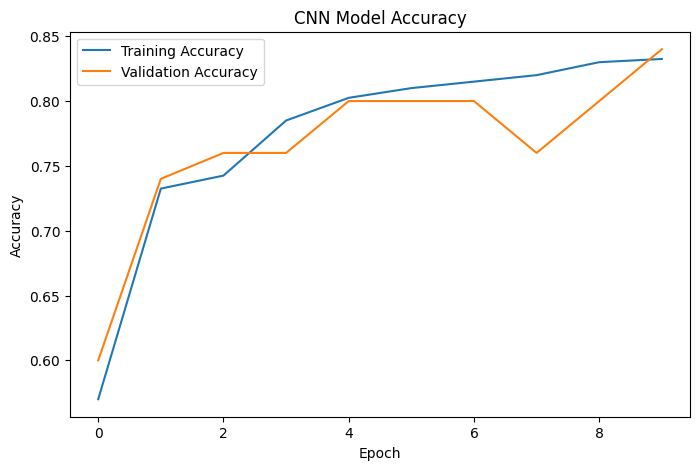

In [47]:
#Plot Training Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

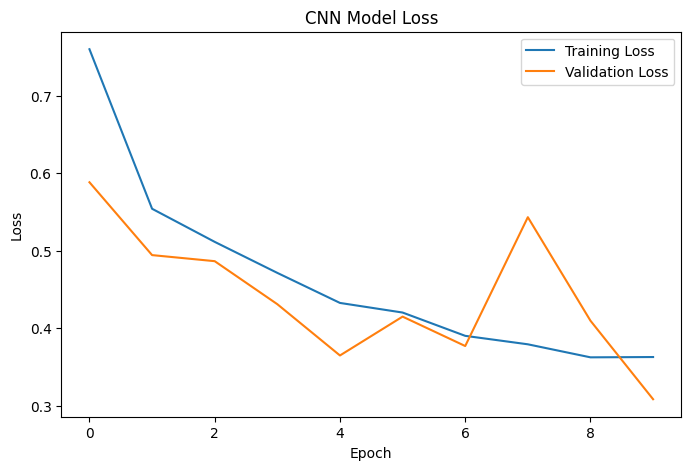

In [48]:
#Plot Training Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [49]:
#Evaluate on the Test Dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 833ms/step - accuracy: 0.8400 - loss: 0.3314
Test Loss: 0.331411749124527
Test Accuracy: 0.8399999737739563


In [50]:
#saving the model
model.save("/content/real_vs_ai_cnn.keras")

print("CNN model saved successfully!")

CNN model saved successfully!


In [51]:
#Getting Predictions
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")

Predictions generated successfully!


Confusion Matrix:
[[25  0]
 [ 8 17]]


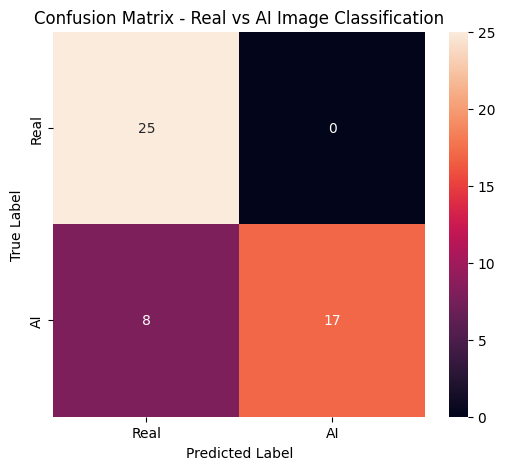

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Real", "AI"],
    yticklabels=["Real", "AI"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Real vs AI Image Classification")

plt.show()

In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Real', 'AI']
))

              precision    recall  f1-score   support

        Real       0.76      1.00      0.86        25
          AI       1.00      0.68      0.81        25

    accuracy                           0.84        50
   macro avg       0.88      0.84      0.84        50
weighted avg       0.88      0.84      0.84        50



In [54]:
#ROC & AUC
from sklearn.metrics import roc_curve, auc

# Get probability predictions
y_prob = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    y_prob.extend(predictions.flatten())

y_prob = np.array(y_prob)

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9584


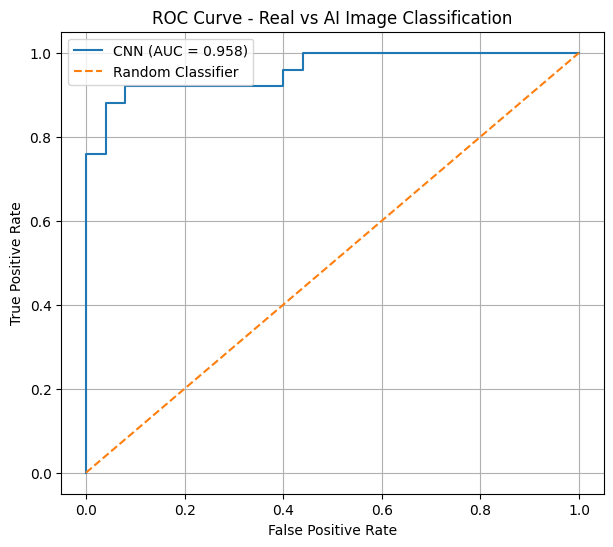

In [55]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f'CNN (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Real vs AI Image Classification')
plt.legend()
plt.grid()

plt.show()

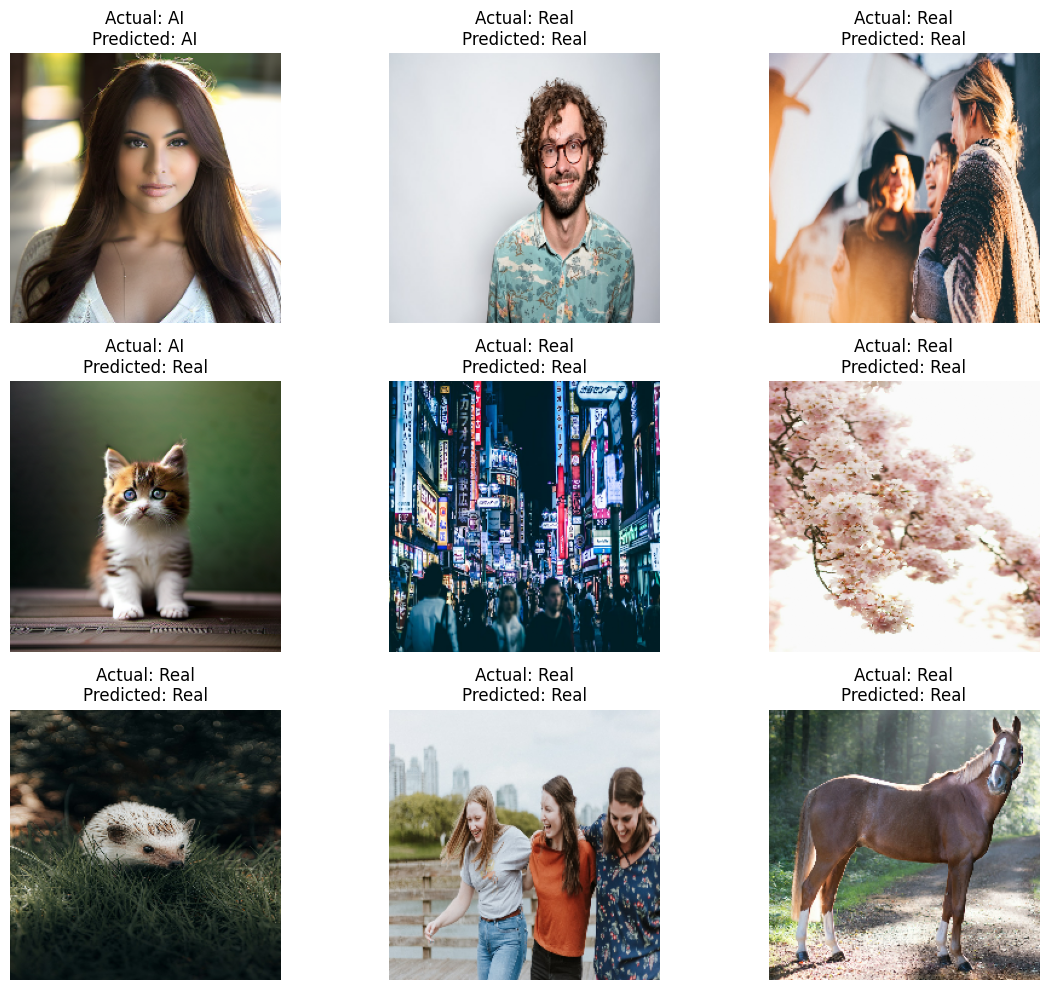

In [56]:
import matplotlib.pyplot as plt

class_names = ['Real', 'AI']

plt.figure(figsize=(12, 10))

for images, labels in test_dataset.take(1):

    predictions = model.predict(images, verbose=0)

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])

        actual = class_names[int(labels[i].numpy())]
        predicted = class_names[int(predictions[i][0] >= 0.5)]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
incorrect_indices = np.where(y_true != y_pred)[0]

print("Total test images:", len(y_true))
print("Incorrect predictions:", len(incorrect_indices))
print(
    "Incorrect prediction percentage:",
    len(incorrect_indices) / len(y_true) * 100,
    "%"
)

Total test images: 50
Incorrect predictions: 8
Incorrect prediction percentage: 16.0 %


In [58]:
model.save("/content/real_vs_ai_cnn.keras")

print("CNN model saved successfully!")

CNN model saved successfully!


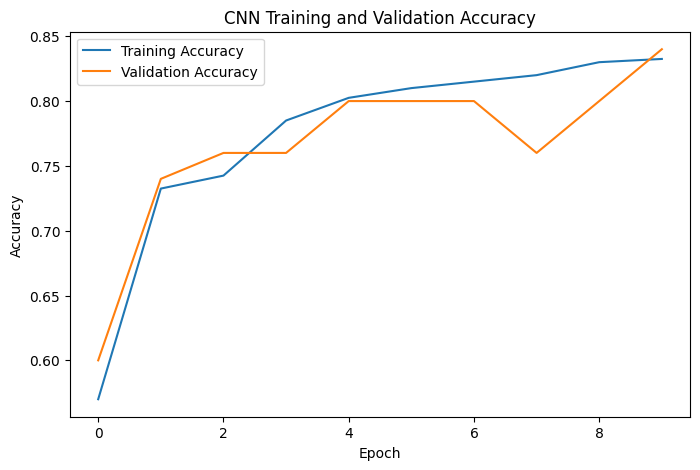

In [62]:
#Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig(
    "/content/cnn_accuracy.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

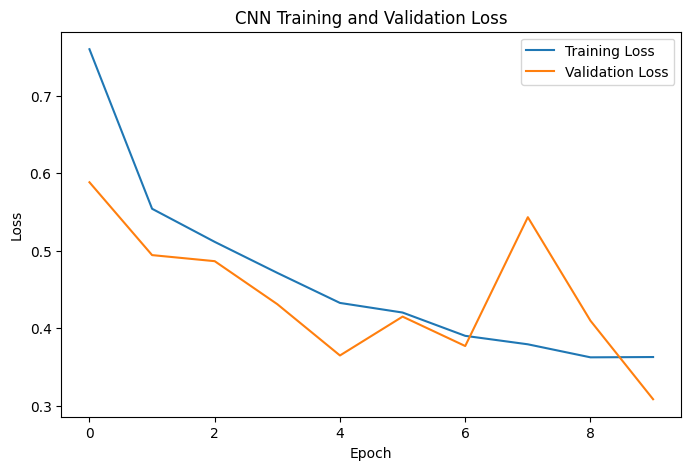

In [61]:
#Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig(
    "/content/cnn_loss.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [64]:
#exact classification report
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=['Real', 'AI'],
    digits=4
)

print(report)

              precision    recall  f1-score   support

        Real     0.7576    1.0000    0.8621        25
          AI     1.0000    0.6800    0.8095        25

    accuracy                         0.8400        50
   macro avg     0.8788    0.8400    0.8358        50
weighted avg     0.8788    0.8400    0.8358        50



In [65]:
# Analyze errors by category

results_df = test_df.copy()

results_df["actual"] = y_true
results_df["predicted"] = y_pred

results_df["correct"] = (
    results_df["actual"] == results_df["predicted"]
)

print("Errors by category:")
print(
    results_df[results_df["correct"] == False]["category"]
    .value_counts()
)

Errors by category:
category
nature     3
food       2
animals    1
people     1
city       1
Name: count, dtype: int64


In [66]:
print("\nAccuracy by category:")

category_accuracy = (
    results_df
    .groupby("category")["correct"]
    .mean()
    .sort_values(ascending=False)
)

print(category_accuracy)


Accuracy by category:
category
people     0.937500
animals    0.900000
city       0.875000
food       0.777778
nature     0.571429
Name: correct, dtype: float64
